In [13]:
import numpy as np
import matplotlib.pyplot as plt

def load_data():
    """Load log-likelihoods and labels data"""
    # For multiclass problem
    ll = np.load("data/commedia_ll.npy")
    labels = np.load("data/commedia_labels.npy")

    # For binary problem (Inferno vs Paradiso)
    llr_infpar = np.load("data/commedia_llr_infpar.npy")
    labels_infpar = np.load("data/commedia_labels_infpar.npy")

    # For comparison (epsilon=1.0)
    llr_infpar_eps1 = np.load("data/commedia_llr_infpar_eps1.npy")

    return ll, labels, llr_infpar, labels_infpar, llr_infpar_eps1

def compute_confusion_matrix(predicted_labels, true_labels, num_classes):
    """Compute confusion matrix from predicted and true labels"""
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(len(true_labels)):
        conf_matrix[predicted_labels[i], true_labels[i]] += 1
    return conf_matrix

def compute_predictions(ll_matrix, priors=None):
    """Compute predictions from log-likelihoods with given priors"""
    num_classes = ll_matrix.shape[0]

    # Use uniform priors if none provided
    if priors is None:
        priors = np.ones(num_classes) / num_classes

    # Compute joint log-likelihoods and find max for each sample
    log_priors = np.log(priors).reshape(-1, 1)
    joint_ll = ll_matrix + log_priors
    predictions = np.argmax(joint_ll, axis=0)

    return predictions

# Load data
ll, labels, _, _, _ = load_data()

# Compute predictions with uniform priors
predictions = compute_predictions(ll)

# Compute confusion matrix
num_classes = ll.shape[0]
conf_matrix = compute_confusion_matrix(predictions, labels, num_classes)

print("Confusion Matrix with Uniform Priors:")
print(conf_matrix)
# Expected output:
# [[210 113  61]
#  [137 191 111]
#  [ 53  98 230]]

Confusion Matrix with Uniform Priors:
[[210 113  61]
 [137 191 111]
 [ 53  98 230]]


In [14]:
def optimal_binary_decisions(llr, prior1, Cfn, Cfp):
    """Compute optimal Bayes decisions for binary classification"""
    # Compute theoretical threshold
    threshold = -np.log((prior1 * Cfn) / ((1 - prior1) * Cfp))

    # Make decisions by comparing LLR to threshold
    predictions = np.zeros(llr.shape, dtype=int)
    predictions[llr > threshold] = 1

    return predictions

def binary_confusion_matrix(predictions, true_labels):
    """Compute 2x2 confusion matrix for binary classification"""
    conf_matrix = np.zeros((2, 2), dtype=int)
    for i in range(len(true_labels)):
        conf_matrix[predictions[i], true_labels[i]] += 1
    return conf_matrix

# Load binary data
_, _, llr_infpar, labels_infpar, _ = load_data()

# Define application scenarios (prior1, Cfn, Cfp)
applications = [
    (0.5, 1, 1),   # Equal priors and costs
    (0.8, 1, 1),   # Higher prior for class 1
    (0.5, 10, 1),  # Higher cost for false negatives
    (0.8, 1, 10),  # Higher cost for false positives
]

# Compute predictions and confusion matrices for each scenario
for prior1, Cfn, Cfp in applications:
    predictions = optimal_binary_decisions(llr_infpar, prior1, Cfn, Cfp)
    conf_matrix = binary_confusion_matrix(predictions, labels_infpar)

    print(f"\nConfusion matrix for (π₁={prior1}, Cfn={Cfn}, Cfp={Cfp}):")
    print(conf_matrix)


Confusion matrix for (π₁=0.5, Cfn=1, Cfp=1):
[[293  96]
 [109 304]]

Confusion matrix for (π₁=0.8, Cfn=1, Cfp=1):
[[271  80]
 [131 320]]

Confusion matrix for (π₁=0.5, Cfn=10, Cfp=1):
[[257  75]
 [145 325]]

Confusion matrix for (π₁=0.8, Cfn=1, Cfp=10):
[[302 113]
 [100 287]]


In [21]:
def compute_error_rates(conf_matrix):
    """Compute false negative and false positive rates from confusion matrix"""
    # Extract values from confusion matrix
    tn, fn = conf_matrix[0, 0], conf_matrix[0, 1]
    fp, tp = conf_matrix[1, 0], conf_matrix[1, 1]

    # Compute rates (handle division by zero)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return fnr, fpr

def compute_dcf(conf_matrix, prior1, Cfn, Cfp):
    """Compute unnormalized and normalized DCF"""
    fnr, fpr = compute_error_rates(conf_matrix)

    # Compute unnormalized DCF
    dcf_u = prior1 * Cfn * fnr + (1 - prior1) * Cfp * fpr

    # Compute normalized DCF
    dcf_dummy = min(prior1 * Cfn, (1 - prior1) * Cfp)
    dcf = dcf_u / dcf_dummy

    return dcf_u, dcf

# Evaluate classifier for each application scenario
for prior1, Cfn, Cfp in applications:
    predictions = optimal_binary_decisions(llr_infpar, prior1, Cfn, Cfp)
    conf_matrix = binary_confusion_matrix(predictions, labels_infpar)

    dcf_u, dcf = compute_dcf(conf_matrix, prior1, Cfn, Cfp)

    print(f"\nEvaluation for (π₁={prior1}, Cfn={Cfn}, Cfp={Cfp}):")
    print(f"Unnormalized DCF = {dcf_u:.3f}")
    print(f"Normalized DCF = {dcf:.3f}")


Evaluation for (π₁=0.5, Cfn=1, Cfp=1):
Unnormalized DCF = 0.256
Normalized DCF = 0.511

Evaluation for (π₁=0.8, Cfn=1, Cfp=1):
Unnormalized DCF = 0.225
Normalized DCF = 1.126

Evaluation for (π₁=0.5, Cfn=10, Cfp=1):
Unnormalized DCF = 1.118
Normalized DCF = 2.236

Evaluation for (π₁=0.8, Cfn=1, Cfp=10):
Unnormalized DCF = 0.724
Normalized DCF = 0.904


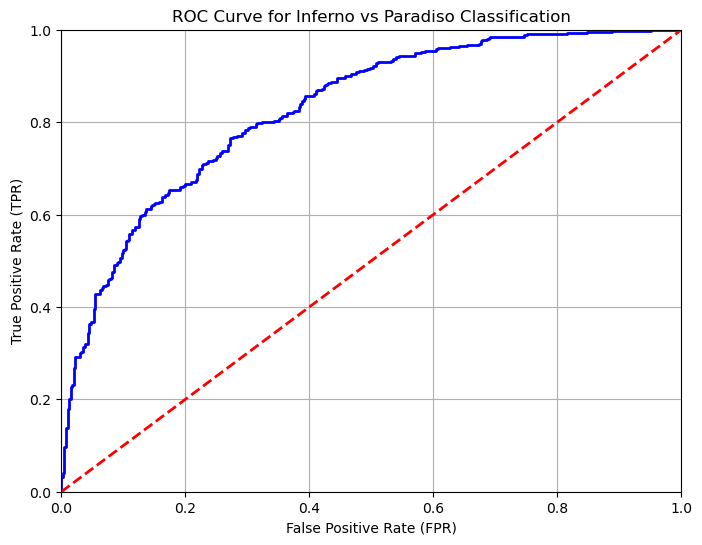

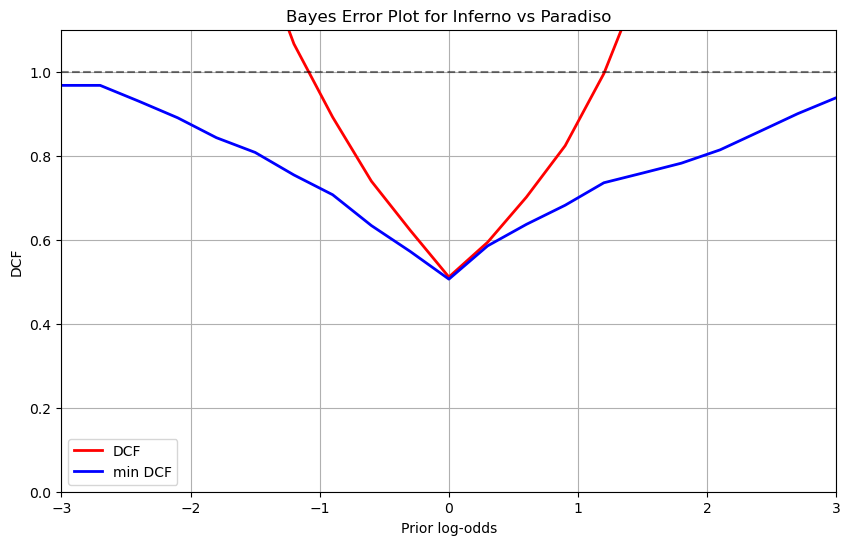

In [20]:
def compute_min_dcf(llr, true_labels, prior1, Cfn, Cfp):
    """Compute minimum DCF by trying all possible thresholds"""
    # Sort scores and corresponding labels
    indices = np.argsort(llr)
    sorted_llr = llr[indices]
    sorted_labels = true_labels[indices]

    # Initialize variables
    min_dcf = float('inf')
    optimal_threshold = None

    # Try all possible thresholds (including -inf and +inf)
    thresholds = np.concatenate([[-np.inf], sorted_llr, [np.inf]])

    for t in thresholds:
        # Make predictions with current threshold
        predictions = np.zeros_like(true_labels)
        predictions[llr > t] = 1

        # Compute confusion matrix and DCF
        conf_matrix = binary_confusion_matrix(predictions, true_labels)
        _, dcf = compute_dcf(conf_matrix, prior1, Cfn, Cfp)

        # Update minimum DCF if better
        if dcf < min_dcf:
            min_dcf = dcf
            optimal_threshold = t

    return min_dcf, optimal_threshold

def compute_roc_curve(llr, true_labels):
    """Compute ROC curve points by varying the threshold"""
    # Initialize lists to store FPR and TPR values
    fpr_list = []
    tpr_list = []

    # Try different thresholds
    thresholds = np.concatenate([[-np.inf], np.sort(llr), [np.inf]])

    for t in thresholds:
        # Make predictions with current threshold
        predictions = np.zeros_like(true_labels)
        predictions[llr > t] = 1

        # Compute confusion matrix and error rates
        conf_matrix = binary_confusion_matrix(predictions, true_labels)
        fnr, fpr = compute_error_rates(conf_matrix)
        tpr = 1 - fnr

        fpr_list.append(fpr)
        tpr_list.append(tpr)

    return np.array(fpr_list), np.array(tpr_list)

def plot_roc_curve(fpr, tpr, title="ROC Curve"):
    """Plot ROC curve"""
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2)  # Random classifier reference

    plt.grid(True)
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(title)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

# Compute and plot ROC curve
fpr, tpr = compute_roc_curve(llr_infpar, labels_infpar)
plot_roc_curve(fpr, tpr, "ROC Curve for Inferno vs Paradiso Classification")

def compute_bayes_error_plot(llr, true_labels, prior_log_odds_range=(-3, 3), num_points=21):
    """Compute DCF and min DCF for multiple effective priors"""
    # Generate prior log-odds values
    prior_log_odds = np.linspace(prior_log_odds_range[0], prior_log_odds_range[1], num_points)

    # Convert to effective priors
    effective_priors = 1 / (1 + np.exp(-prior_log_odds))

    dcf_list = []
    min_dcf_list = []

    # Compute DCF and min DCF for each effective prior
    for p in effective_priors:
        # Actual DCF
        predictions = optimal_binary_decisions(llr, p, 1, 1)
        conf_matrix = binary_confusion_matrix(predictions, true_labels)
        _, dcf = compute_dcf(conf_matrix, p, 1, 1)

        # Minimum DCF
        min_dcf, _ = compute_min_dcf(llr, true_labels, p, 1, 1)

        dcf_list.append(dcf)
        min_dcf_list.append(min_dcf)

    return prior_log_odds, np.array(dcf_list), np.array(min_dcf_list)

def plot_bayes_error(prior_log_odds, dcf, min_dcf, title="Bayes Error Plot"):
    """Plot Bayes error curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(prior_log_odds, dcf, 'r-', linewidth=2, label='DCF')
    plt.plot(prior_log_odds, min_dcf, 'b-', linewidth=2, label='min DCF')

    # Add reference line for dummy system
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)

    plt.grid(True)
    plt.xlabel('Prior log-odds')
    plt.ylabel('DCF')
    plt.title(title)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.xlim([-3, 3])
    plt.show()

# Compute and plot Bayes error plot
prior_log_odds, dcf, min_dcf = compute_bayes_error_plot(llr_infpar, labels_infpar)
plot_bayes_error(prior_log_odds, dcf, min_dcf, "Bayes Error Plot for Inferno vs Paradiso")

In [22]:
def compare_classifiers(llr_dict, true_labels, applications):
    """Compare multiple classifiers using DCF and min DCF metrics"""
    # Initialize results dictionary
    results = {model: [] for model in llr_dict}

    # Evaluate each model for each application
    for prior1, Cfn, Cfp in applications:
        for model, llr in llr_dict.items():
            # Compute actual DCF
            predictions = optimal_binary_decisions(llr, prior1, Cfn, Cfp)
            conf_matrix = binary_confusion_matrix(predictions, true_labels)
            _, dcf = compute_dcf(conf_matrix, prior1, Cfn, Cfp)

            # Compute minimum DCF
            min_dcf, _ = compute_min_dcf(llr, true_labels, prior1, Cfn, Cfp)

            results[model].append((dcf, min_dcf))

    # Print comparison table
    print("\nModel Comparison:")
    print("-" * 60)
    print(f"{'Application':<15} | {'Model':<15} | {'DCF':>8} | {'min DCF':>8}")
    print("-" * 60)

    # Print results for each application and model
    for i, (prior1, Cfn, Cfp) in enumerate(applications):
        app_name = f"π₁={prior1}, C={Cfn}/{Cfp}"
        for j, model in enumerate(llr_dict):
            dcf, min_dcf = results[model][i]
            print(f"{app_name if j == 0 else '':<15} | {model:<15} | {dcf:8.3f} | {min_dcf:8.3f}")
        print("-" * 60)

    return results

def compute_multiclass_dcf(conf_matrix, priors, cost_matrix):
    """Compute Detection Cost Function for multiclass problems"""
    num_classes = conf_matrix.shape[0]

    # Initialize empirical ratios matrix
    emp_ratios = np.zeros_like(conf_matrix, dtype=float)

    # Compute empirical ratios
    for j in range(num_classes):
        col_sum = np.sum(conf_matrix[:, j])
        if col_sum > 0:
            emp_ratios[:, j] = conf_matrix[:, j] / col_sum

    # Compute unnormalized DCF
    class_costs = np.zeros(num_classes)
    for j in range(num_classes):
        class_costs[j] = np.sum(emp_ratios[:, j] * cost_matrix[:, j])

    dcf_u = np.sum(priors * class_costs)

    # Compute the cost of a "dummy" system
    dummy_costs = np.dot(cost_matrix, priors)
    dcf_dummy = np.min(dummy_costs)

    # Compute normalized DCF
    dcf = dcf_u / dcf_dummy

    return dcf_u, dcf

def multiclass_optimal_decisions(ll_matrix, cost_matrix, priors):
    """Compute optimal Bayes decisions for multiclass classification"""
    num_classes = ll_matrix.shape[0]

    # Compute joint log-likelihoods
    log_priors = np.log(priors).reshape(-1, 1)
    joint_ll = ll_matrix + log_priors

    # Compute expected costs for each decision
    expected_costs = np.zeros((num_classes, ll_matrix.shape[1]))
    for i in range(num_classes):  # For each possible decision
        for j in range(num_classes):  # For each possible class
            # P(class j) * cost of deciding i when actual class is j
            expected_costs[i] += np.exp(joint_ll[j]) * cost_matrix[i, j]

    # Choose the decision that minimizes the expected cost
    predictions = np.argmin(expected_costs, axis=0)

    return predictions

# Load multiclass data
ll, labels, _, _, _ = load_data()

# Cost matrix from specifications
cost_matrix = np.array([
    [0, 1, 2],
    [1, 0, 1],
    [2, 1, 0]
])

# Prior probabilities
priors = np.array([0.3, 0.4, 0.3])

# Compute optimal decisions
predictions = multiclass_optimal_decisions(ll, cost_matrix, priors)

# Compute confusion matrix
num_classes = ll.shape[0]
conf_matrix = compute_confusion_matrix(predictions, labels, num_classes)

print("\nMulticlass Evaluation:")
print("Confusion Matrix:")
print(conf_matrix)

# Compute DCF
dcf_u, dcf = compute_multiclass_dcf(conf_matrix, priors, cost_matrix)
print(f"Unnormalized DCF = {dcf_u:.3f}")
print(f"Normalized DCF = {dcf:.3f}")

# Also evaluate with uniform priors and costs
uniform_priors = np.ones(num_classes) / num_classes
uniform_cost = np.ones((num_classes, num_classes)) - np.eye(num_classes)

uniform_predictions = multiclass_optimal_decisions(ll, uniform_cost, uniform_priors)
uniform_conf_matrix = compute_confusion_matrix(uniform_predictions, labels, num_classes)

print("\nWith Uniform Priors and Costs:")
print("Confusion Matrix:")
print(uniform_conf_matrix)

uniform_dcf_u, uniform_dcf = compute_multiclass_dcf(uniform_conf_matrix, uniform_priors, uniform_cost)
print(f"Unnormalized DCF = {uniform_dcf_u:.3f}")
print(f"Normalized DCF = {uniform_dcf:.3f}")


Multiclass Evaluation:
Confusion Matrix:
[[205 111  56]
 [145 199 121]
 [ 50  92 225]]
Unnormalized DCF = 0.560
Normalized DCF = 0.933

With Uniform Priors and Costs:
Confusion Matrix:
[[210 113  61]
 [137 191 111]
 [ 53  98 230]]
Unnormalized DCF = 0.476
Normalized DCF = 0.714
